In [1]:
from pathlib import Path
import dask.dataframe as dd
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import polars as pl

In [2]:
YEAR = 2021
CHUNKS_FOLDERPATH = Path(F"../data/silver/ghana-{YEAR}-chunks")
DF_FILEPATH = Path(F'../data/silver/ghana-{YEAR}-df.parquet')

# Load data

In [3]:
ddf = dd.read_parquet(CHUNKS_FOLDERPATH / "*.parquet")
print(f"# rows: {len(ddf)}")
ddf

# rows: 24213205


,lon,lat,red,green,blue,rededge,B06,B07,nir,B8A,swir11,swir22,cloud_confidence,scene_classification,valid_observations,ethz_map,tci,ndvi,evi,evi2,ndre_b5,ndre_b6,ndre_b7,gndvi,ndwi,red_3x3_median,red_3x3_min,red_3x3_max,red_3x3_var,green_3x3_median,green_3x3_min,green_3x3_max,green_3x3_var,blue_3x3_median,blue_3x3_min,blue_3x3_max,blue_3x3_var,rededge_3x3_median,rededge_3x3_min,rededge_3x3_max,rededge_3x3_var,B06_3x3_median,B06_3x3_min,B06_3x3_max,B06_3x3_var,B07_3x3_median,B07_3x3_min,B07_3x3_max,B07_3x3_var,nir_3x3_median,nir_3x3_min,nir_3x3_max,nir_3x3_var,B8A_3x3_median,B8A_3x3_min,B8A_3x3_max,B8A_3x3_var,swir11_3x3_median,swir11_3x3_min,swir11_3x3_max,swir11_3x3_var,swir22_3x3_median,swir22_3x3_min,swir22_3x3_max,swir22_3x3_var,cloud_confidence_3x3_median,cloud_confidence_3x3_min,cloud_confidence_3x3_max,cloud_confidence_3x3_var,tci_3x3_median,tci_3x3_min,tci_3x3_max,tci_3x3_var,ndvi_3x3_median,ndvi_3x3_min,ndvi_3x3_max,ndvi_3x3_var,evi_3x3_median,evi_3x3_min,evi_3x3_max,evi_3x3_var,evi2_3x3_median,evi2_3x3_min,evi2_3x3_max,evi2_3x3_var,ndre_b5_3x3_median,ndre_b5_3x3_min,ndre_b5_3x3_max,ndre_b5_3x3_var,ndre_b6_3x3_median,ndre_b6_3x3_min,ndre_b6_3x3_max,ndre_b6_3x3_var,ndre_b7_3x3_median,ndre_b7_3x3_min,ndre_b7_3x3_max,ndre_b7_3x3_var,gndvi_3x3_median,gndvi_3x3_min,gndvi_3x3_max,gndvi_3x3_var,ndwi_3x3_median,ndwi_3x3_min,ndwi_3x3_max,ndwi_3x3_var,red_5x5_median,red_5x5_min,red_5x5_max,red_5x5_var,green_5x5_median,green_5x5_min,green_5x5_max,green_5x5_var,blue_5x5_median,blue_5x5_min,blue_5x5_max,blue_5x5_var,rededge_5x5_median,rededge_5x5_min,rededge_5x5_max,rededge_5x5_var,B06_5x5_median,B06_5x5_min,B06_5x5_max,B06_5x5_var,B07_5x5_median,B07_5x5_min,B07_5x5_max,B07_5x5_var,nir_5x5_median,nir_5x5_min,nir_5x5_max,nir_5x5_var,B8A_5x5_median,B8A_5x5_min,B8A_5x5_max,B8A_5x5_var,swir11_5x5_median,swir11_5x5_min,swir11_5x5_max,swir11_5x5_var,swir22_5x5_median,swir22_5x5_min,swir22_5x5_max,swir22_5x5_var,cloud_confidence_5x5_median,cloud_confidence_5x5_min,cloud_confidence_5x5_max,cloud_confidence_5x5_var,tci_5x5_median,tci_5x5_min,tci_5x5_max,tci_5x5_var,ndvi_5x5_median,ndvi_5x5_min,ndvi_5x5_max,ndvi_5x5_var,evi_5x5_median,evi_5x5_min,evi_5x5_max,evi_5x5_var,evi2_5x5_median,evi2_5x5_min,evi2_5x5_max,evi2_5x5_var,ndre_b5_5x5_median,ndre_b5_5x5_min,ndre_b5_5x5_max,ndre_b5_5x5_var,ndre_b6_5x5_median,ndre_b6_5x5_min,ndre_b6_5x5_max,ndre_b6_5x5_var,ndre_b7_5x5_median,ndre_b7_5x5_min,ndre_b7_5x5_max,ndre_b7_5x5_var,gndvi_5x5_median,gndvi_5x5_min,gndvi_5x5_max,gndvi_5x5_var,ndwi_5x5_median,ndwi_5x5_min,ndwi_5x5_max,ndwi_5x5_var,red_11x11_median,red_11x11_min,red_11x11_max,red_11x11_var,green_11x11_median,green_11x11_min,green_11x11_max,green_11x11_var,blue_11x11_median,blue_11x11_min,blue_11x11_max,blue_11x11_var,rededge_11x11_median,rededge_11x11_min,rededge_11x11_max,rededge_11x11_var,B06_11x11_median,B06_11x11_min,B06_11x11_max,B06_11x11_var,B07_11x11_median,B07_11x11_min,B07_11x11_max,B07_11x11_var,nir_11x11_median,nir_11x11_min,nir_11x11_max,nir_11x11_var,B8A_11x11_median,B8A_11x11_min,B8A_11x11_max,B8A_11x11_var,swir11_11x11_median,swir11_11x11_min,swir11_11x11_max,swir11_11x11_var,swir22_11x11_median,swir22_11x11_min,swir22_11x11_max,swir22_11x11_var,cloud_confidence_11x11_median,cloud_confidence_11x11_min,cloud_confidence_11x11_max,cloud_confidence_11x11_var,tci_11x11_median,tci_11x11_min,tci_11x11_max,tci_11x11_var,ndvi_11x11_median,ndvi_11x11_min,ndvi_11x11_max,ndvi_11x11_var,evi_11x11_median,evi_11x11_min,evi_11x11_max,evi_11x11_var,evi2_11x11_median,evi2_11x11_min,evi2_11x11_max,evi2_11x11_var,ndre_b5_11x11_median,ndre_b5_11x11_min,ndre_b5_11x11_max,ndre_b5_11x11_var,ndre_b6_11x11_median,ndre_b6_11x11_min,ndre_b6_11x11_max,ndre_b6_11x11_var,ndre_b7_11x11_median,ndre_b7_11x11_min,ndre_b7_11x11_max,ndre_b7_11x11_var,gndvi_11x11_median,gndvi_11x11_min,gndvi_11x11_max,gndvi_11x11_var,ndwi_11x11_median,ndwi_11x11_min,ndwi_11x11_max,ndwi_11x11_var
npartitions=148,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,

In [4]:
# Subsample
ddf = ddf.sample(frac=1_000_000/len(ddf))

In [5]:
# Load in RAM
df = ddf.compute().reset_index(drop=True)
df.head(1)

,lon,lat,red,green,blue,rededge,B06,B07,nir,B8A,...,ndre_b7_11x11_max,ndre_b7_11x11_var,gndvi_11x11_median,gndvi_11x11_min,gndvi_11x11_max,gndvi_11x11_var,ndwi_11x11_median,ndwi_11x11_min,ndwi_11x11_max,ndwi_11x11_var
0,-0.249615,11.155107,37,27,19,48,52,55,55,58,...,0.035714,0.000042,0.358974,0.285714,0.410256,0.000471,1.731343,1.589041,1.957265,0.00298


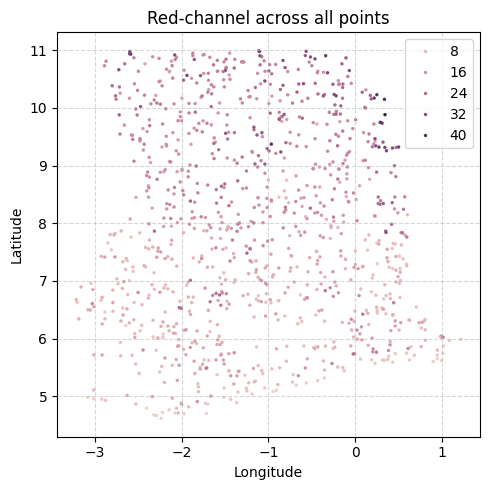

In [6]:
# Plot the data
plt.figure(figsize=(5, 5))
sns.scatterplot(data=df.sample(1_000), x='lon', y='lat', hue='red', s=5, alpha=1.0, edgecolor=None)

plt.title('Red-channel across all points')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# Cleanup

In [7]:
# Convert ETHZ-map (int) to y (float), and bool
ETHZ_MAP_NAN = 65535 # uint16 value used to represent NaN in the ETHZ-map

# Discard NaNs
mask = df['ethz_map'] != ETHZ_MAP_NAN
df = df[mask].copy() # Explicit copy prevents SettingWithCopyWarning downstream
print(f"Discarding ETHZ-map NaN's: Kept {mask.sum()}/{len(mask)} ({mask.mean():.2%})")

# Cleanup 
df['y'] = df['ethz_map'] > 650
df = df.drop(columns=['ethz_map'])

df.head(1)

Discarding ETHZ-map NaN's: Kept 944808/999998 (94.48%)


,lon,lat,red,green,blue,rededge,B06,B07,nir,B8A,...,ndre_b7_11x11_var,gndvi_11x11_median,gndvi_11x11_min,gndvi_11x11_max,gndvi_11x11_var,ndwi_11x11_median,ndwi_11x11_min,ndwi_11x11_max,ndwi_11x11_var,y
0,-0.249615,11.155107,37,27,19,48,52,55,55,58,...,0.000042,0.358974,0.285714,0.410256,0.000471,1.731343,1.589041,1.957265,0.00298,False


Setting NaN's in S2's bands...


100%|███████████████████████████████████████████████████████████████████████████████████████████| 130/130 [00:00<00:00, 533.61it/s]


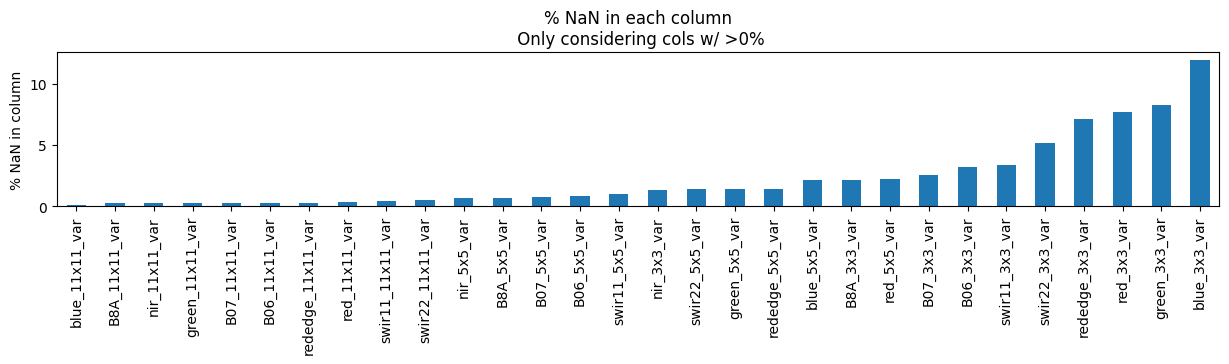

In [8]:
# Place NaN

S2_NAN = 0
band_names = ["red", "green", "blue", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
s2_band_cols = [e for e in df.columns if e.startswith(tuple(band_names))]

print("Setting NaN's in S2's bands...")

# Iterate through columns one by one to prevent memory spikes
for col in tqdm(s2_band_cols):
    df.loc[df[col] == S2_NAN, col] = np.nan

# Calculate percentage of NaNs
nan_df = df.isna().sum() / len(df) * 100

# Plotting
plt.figure(figsize=(15, 2))
plt.title('% NaN in each column\n Only considering cols w/ >0%')
plt.ylabel('% NaN in column')
nan_df[nan_df > 0].sort_values().plot(kind='bar')
plt.show()

In [9]:
# Convert bands to 0-1 values
band_cols = [e for e in df.columns if e not in ('lon', 'lat', 'y')]
band_cols = [e for e in band_cols if not any(e.startswith(prefix) for prefix in ('cloud_confidence', 'scene_classification', 'valid_observations'))]

for col in tqdm(band_cols):
    df[col] =  df[col] / 255

df.head(1)

100%|███████████████████████████████████████████████████████████████████████████████████████████| 247/247 [00:00<00:00, 937.23it/s]


,lon,lat,red,green,blue,rededge,B06,B07,nir,B8A,...,ndre_b7_11x11_var,gndvi_11x11_median,gndvi_11x11_min,gndvi_11x11_max,gndvi_11x11_var,ndwi_11x11_median,ndwi_11x11_min,ndwi_11x11_max,ndwi_11x11_var,y
0,-0.249615,11.155107,0.145098,0.105882,0.07451,0.188235,0.203922,0.215686,0.215686,0.227451,...,1.662564e-07,0.001408,0.00112,0.001609,0.000002,0.00679,0.006232,0.007676,0.000012,False


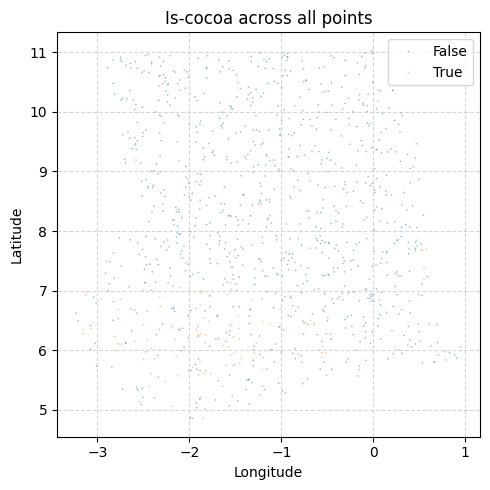

In [10]:
# Plot the data
plt.figure(figsize=(5, 5))
sns.scatterplot(data=df.sample(1_000), x='lon', y='lat', hue='y', s=1, alpha=0.5, edgecolor=None)

plt.title('Is-cocoa across all points')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# Figure out in which region each point is

In [11]:
# Figure out in which region each point is
import pandas as pd
import geopandas as gpd

gdf_points = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['lon'], df['lat']), crs="EPSG:4326")

ghana_regions = gpd.read_file('../data/bronze/gadm41_GHA.gpkg', layer='ADM_ADM_1')
ghana_regions = ghana_regions.to_crs("EPSG:4326")

# Spatial join
joined = gpd.sjoin(gdf_points, ghana_regions, how="left", predicate="within")

# Fix slightly out-of-bound
matched = joined[joined['NAME_1'].notna()]
unmatched = joined[joined['NAME_1'].isna()].copy()

if not unmatched.empty:
    # Drop the empty columns from the unsuccessful join to avoid duplicates
    cols_to_drop = ghana_regions.columns.drop('geometry').tolist() + ['index_right']
    unmatched_clean = unmatched.drop(columns=cols_to_drop, errors='ignore')

    # IMPORTANT: Use unmatched_clean here!
    unmatched_fixed = gpd.sjoin_nearest(unmatched_clean, ghana_regions, how="left", distance_col="distance")

    # Recombine the matched and the newly fixed unmatched points
    joined = pd.concat([matched, unmatched_fixed])

# Finally, assign the result back to your original dataframe
df['region'] = joined['NAME_1'].astype('category')

/home/aga/Documents/clients/forestero/skymap/skymap/.venv/lib/python3.14/site-packages/geopandas/array.py:411: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(
/tmp/ipykernel_22986/113184014.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['region'] = joined['NAME_1'].astype('category')


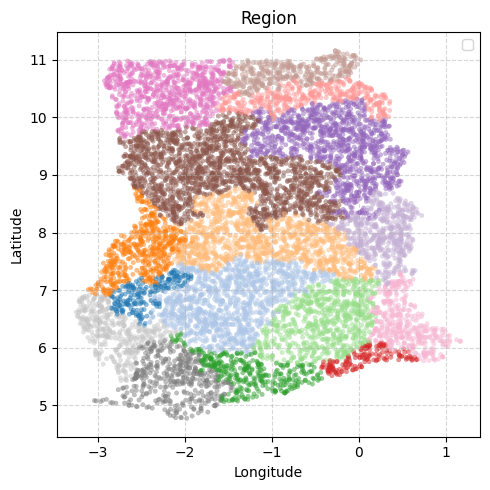

In [14]:
# Plot the data
plt.figure(figsize=(5, 5))
sns.scatterplot(data=df.sample(10_000), x='lon', y='lat', hue='region', palette='tab20', s=10, alpha=0.5, edgecolor=None)

plt.title('Region')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend([])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# Feature engineering

In [15]:
# SCL
# The SCL flags a lot of px as cloud and whatnot, but not vegetation
SCL_IDX_TO_SCL_NAME = {
    0: 'NO_DATA',
    1: 'DEFECTIVE_PX',
    2: 'TOPO_SHADOW',
    3: 'CLOUD_SHADOW',
    4: 'VEGETATION',
    5: 'NOT_VEGETATED',
    6: 'WATER',
    7: 'UNCLASSIFIED',
    8: 'CLOUD_MED_PROB',
    9: 'CLOUD_HIGH_PROB',
    10: 'THIN_CIRRUS',
    11: 'SNOW_OR_ICE',
}

df['scl'] = df.scene_classification.map(SCL_IDX_TO_SCL_NAME).astype('category')
df = df.drop(columns=['scene_classification']).copy()
df.head(1)

/tmp/ipykernel_22986/3624374248.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['scl'] = df.scene_classification.map(SCL_IDX_TO_SCL_NAME).astype('category')


,lon,lat,red,green,blue,rededge,B06,B07,nir,B8A,...,gndvi_11x11_min,gndvi_11x11_max,gndvi_11x11_var,ndwi_11x11_median,ndwi_11x11_min,ndwi_11x11_max,ndwi_11x11_var,y,region,scl
0,-0.249615,11.155107,0.145098,0.105882,0.07451,0.188235,0.203922,0.215686,0.215686,0.227451,...,0.00112,0.001609,0.000002,0.00679,0.006232,0.007676,0.000012,False,Upper East,NOT_VEGETATED


# Dump

In [17]:
df.to_parquet(DF_FILEPATH)